In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 15,
    'axes.titleweight': '500',
    'axes.labelsize': 12,
})

annual = pd.read_csv("../data/processed/annual_master.csv")

# WHY we also need DAILY nikkei data here, not just annual:
# COVID's market crash happened over WEEKS in Feb-March 2020,
# not a full year. Annual averages completely hide this — 
# we need daily granularity to see the actual crash shape

nikkei_daily = pd.read_csv("../data/raw/nikkei_raw.csv")
nikkei_daily['Date'] = pd.to_datetime(nikkei_daily['Date'])

print(f"Annual shape: {annual.shape}")
print(f"Daily Nikkei shape: {nikkei_daily.shape}")

Annual shape: (10, 8)
Daily Nikkei shape: (2444, 7)


In [3]:
# WHY filter to Jan-Jun 2020 specifically:
# The crash and initial recovery both happened within this 
# 6-month window. Zooming into just this period (instead of 
# all of 2020) lets us see the actual SHAPE of the crash and 
# bounce, which annual data completely erases

covid_window = nikkei_daily[
    (nikkei_daily['Date'] >= '2020-01-01') &
    (nikkei_daily['Date'] <= '2020-06-30')
].copy()

print(f"Rows: {len(covid_window)}")
print(f"\nPre-crash peak: {covid_window['Close'].max():.0f} "
      f"on {covid_window.loc[covid_window['Close'].idxmax(), 'Date'].date()}")
print(f"Crash bottom: {covid_window['Close'].min():.0f} "
      f"on {covid_window.loc[covid_window['Close'].idxmin(), 'Date'].date()}")

drop_pct = (covid_window['Close'].min() - covid_window['Close'].max()) / covid_window['Close'].max() * 100
print(f"\nPeak-to-trough drop: {drop_pct:.1f}%")

Rows: 119

Pre-crash peak: 24084 on 2020-01-20
Crash bottom: 16553 on 2020-03-19

Peak-to-trough drop: -31.3%


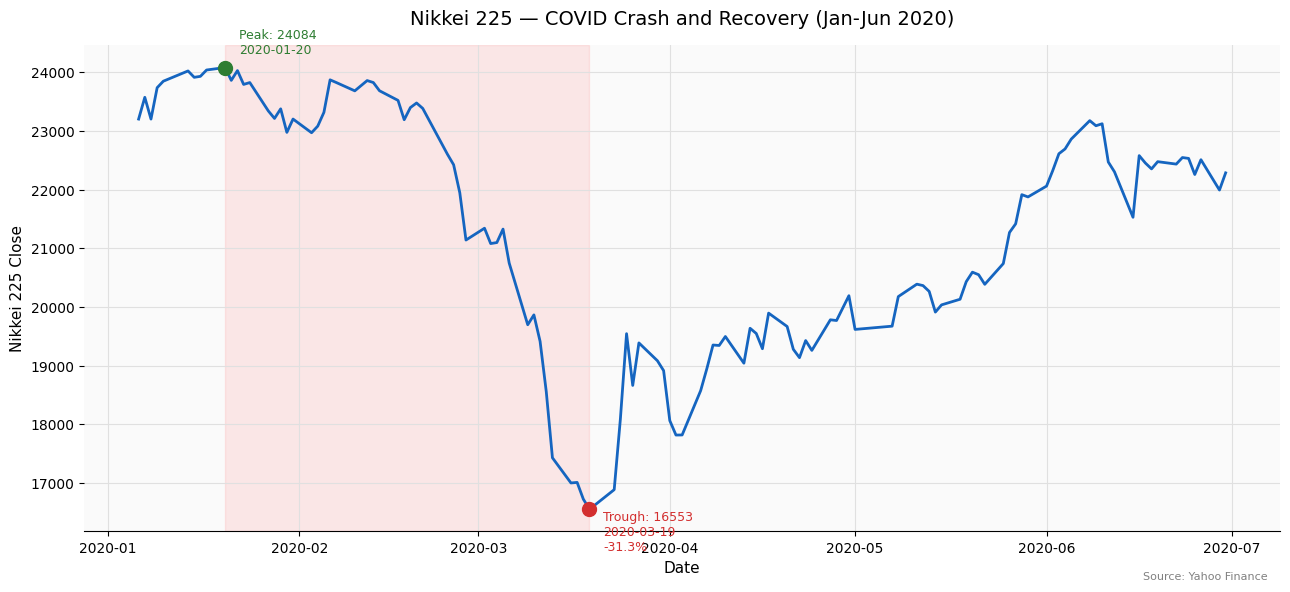

✓ Saved


In [4]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(covid_window['Date'], covid_window['Close'],
        color='#1565C0', linewidth=2)

# Mark peak and trough
peak_date = covid_window.loc[covid_window['Close'].idxmax(), 'Date']
peak_val = covid_window['Close'].max()
trough_date = covid_window.loc[covid_window['Close'].idxmin(), 'Date']
trough_val = covid_window['Close'].min()

ax.scatter([peak_date], [peak_val], color='#2E7D32', s=100, zorder=5)
ax.annotate(f'Peak: {peak_val:.0f}\n{peak_date.date()}',
            xy=(peak_date, peak_val), xytext=(10, 10),
            textcoords='offset points', fontsize=9, color='#2E7D32')

ax.scatter([trough_date], [trough_val], color='#D32F2F', s=100, zorder=5)
ax.annotate(f'Trough: {trough_val:.0f}\n{trough_date.date()}\n-31.3%',
            xy=(trough_date, trough_val), xytext=(10, -30),
            textcoords='offset points', fontsize=9, color='#D32F2F')

ax.axvspan(peak_date, trough_date, alpha=0.08, color='red')

ax.set_title("Nikkei 225 — COVID Crash and Recovery (Jan-Jun 2020)",
             fontsize=14, fontweight='500', pad=15)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Nikkei 225 Close", fontsize=11)
ax.text(0.99, -0.1, 'Source: Yahoo Finance',
        transform=ax.transAxes, fontsize=8, color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/covid_crash.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")

In [5]:
filtered_data = nikkei_daily[
    (nikkei_daily['Date'] > pd.Timestamp('2020-03-19')) &
    (nikkei_daily['Close'] >= 24084)
].copy()

recovery_date = filtered_data['Date'].min()
days_to_recover = recovery_date - trough_date
print(days_to_recover)
print(recovery_date)

231 days 00:00:00
2020-11-05 00:00:00


## Key Finding 7 — Recovering vs Fully Recovered

Nikkei began visibly recovering from its March 2020 trough within 
weeks, but full recovery to its January 2020 peak of 24,084 didn't 
occur until November 5, 2020 — 231 days later. This gap matters 
because someone reading only a quick "market recovering" headline in 
June might assume the losses had already been erased, when in reality 
the Nikkei was still below its pre-crash peak. A market can be 
recovering strongly without being fully recovered.

In [6]:
# WHY show all 4 metrics together for just 2021-2023:
# Individually we've seen each piece (yen weakened, inflation 
# rose, Nikkei kept climbing). Showing them side by side for 
# THIS specific 3-year window makes the full causal chain visible 
# in one table instead of scattered across earlier charts

chain = annual[annual['year'].between(2021, 2023)][
    ['year', 'boj_rate_pct', 'usd_jpy', 'inflation_pct', 'nikkei_avg_close']
].copy()

print(chain.to_string(index=False))

 year  boj_rate_pct    usd_jpy  inflation_pct  nikkei_avg_close
 2021     -0.065500 109.842892      -0.233353      28836.538640
 2022     -0.029500 131.458920       2.497703      27257.789895
 2023      0.003833 140.500120       3.268134      30716.555235


## Key Finding 8 — The 2022-2023 Yen-Inflation-Nikkei Chain

The BOJ held its rate near zero (-0.03% in 2022) while the US Federal 
Reserve raised rates aggressively, creating a widening policy gap 
that drove USD/JPY from 109 in 2021 to 131 in 2022, and further to 
140 by 2023. This weakening yen pushed inflation from -0.23% in 2021 
to 2.49% in 2022 and 3.27% in 2023, as energy and import costs rose 
in yen terms. The same weak yen should have boosted Nikkei by raising 
exporters' yen-denominated profits — yet Nikkei actually dipped 
slightly in 2022 (28,837 to 27,258) before jumping sharply in 2023 
(to 30,717). This is explained by Russia's invasion of Ukraine in 
2022, which triggered a global energy price shock and market-wide 
uncertainty that temporarily canceled out the weak-yen benefit for 
exporters. By 2023, as that initial shock stabilized, the underlying 
weak-yen mechanism reasserted itself cleanly, driving Nikkei to its 
decade high even as inflation climbed further.

In [7]:
# WHY 30-day rolling standard deviation:
# Daily price changes are noisy day to day. A 30-day window 
# smooths that into "how much has this stock been swinging 
# around, on average, over the past month" - similar logic 
# to why we used 3-year rolling average in Japan Trade, just 
# applied to volatility instead of trend

nikkei_daily = nikkei_daily.sort_values('Date').reset_index(drop=True)

# Daily % change first
nikkei_daily['daily_return'] = nikkei_daily['Close'].pct_change() * 100

# 30-day rolling standard deviation of those returns
nikkei_daily['volatility_30d'] = nikkei_daily['daily_return'].rolling(window=30).std()

print(nikkei_daily[['Date', 'Close', 'daily_return', 'volatility_30d']].tail(10))

           Date         Close  daily_return  volatility_30d
2434 2023-12-18  32758.980469     -0.641695        1.083406
2435 2023-12-19  33219.390625      1.405447        1.025847
2436 2023-12-20  33675.941406      1.374350        1.018330
2437 2023-12-21  33140.468750     -1.590075        1.063714
2438 2023-12-22  33169.050781      0.086245        1.030954
2439 2023-12-25  33254.031250      0.256204        1.029987
2440 2023-12-26  33305.851562      0.155832        1.030083
2441 2023-12-27  33681.238281      1.127089        1.046871
2442 2023-12-28  33539.621094     -0.420463        0.945705
2443 2023-12-29  33464.171875     -0.224955        0.945138


In [8]:
nikkei_daily = nikkei_daily.sort_values('Date').reset_index(drop=True)

nikkei_daily['daily_return'] = nikkei_daily['Close'].pct_change() * 100
nikkei_daily['volatility_30d'] = nikkei_daily['daily_return'].rolling(window=30).std()
nikkei_daily['year'] = nikkei_daily['Date'].dt.year

# WHY compare average volatility by year:
# One number per year lets us directly compare 2020 vs 2023
# instead of eyeballing a noisy daily chart

vol_by_year = nikkei_daily.groupby('year')['volatility_30d'].mean().round(3)
print(vol_by_year)

year
2014    1.192
2015    1.237
2016    1.650
2017    0.728
2018    1.075
2019    0.951
2020    1.439
2021    1.151
2022    1.293
2023    0.997
Name: volatility_30d, dtype: float64


## Key Finding 9 — 2016 Was Japan's Most Volatile Year, Not COVID

30-day rolling volatility shows 2016 (1.650) as the most volatile 
year in the entire decade — higher than even the COVID crash year 
of 2020 (1.439). This is likely explained by two compounding shocks 
within the same year: the BOJ's surprise introduction of negative 
interest rate policy in January 2016, followed by the UK's Brexit 
referendum in June 2016, which caught global markets off guard and 
triggered a worldwide flight to safe-haven currencies including the 
yen. This finding is a reminder that volatility and crisis severity 
don't always align with the events that receive the most attention 
in hindsight — a full explanation of this spike would benefit from 
further research beyond this project's scope.

In [9]:
# WHY index all 3 metrics to a common base (2014=100):
# Same technique from Japan Trade's growth index and 
# JapanScope's multi-asset chart - once everything is on 
# a 0-100+ scale relative to 2014, we can meaningfully 
# combine them without GDP's raw size dominating

base_year = 2014

recovery = annual[['year', 'gdp_trillion', 'nikkei_avg_close', 
                    'unemployment_pct']].copy()

# GDP and Nikkei: higher = better, index normally
for col in ['gdp_trillion', 'nikkei_avg_close']:
    base = recovery.loc[recovery['year'] == base_year, col].values[0]
    recovery[col + '_idx'] = (recovery[col] / base * 100)

# WHY unemployment needs INVERTED indexing:
# For GDP/Nikkei, higher index = better (economy grew)
# But for unemployment, LOWER is better (fewer people jobless)
# If we indexed it normally, rising unemployment would 
# wrongly show as a "good" rising number
# Inverting (base/current instead of current/base) flips 
# the direction so higher score = better for ALL 3 metrics consistently

base_unemp = recovery.loc[recovery['year'] == base_year, 'unemployment_pct'].values[0]
recovery['unemployment_pct_idx'] = (base_unemp / recovery['unemployment_pct'] * 100)

# WHY simple average, not weighted:
# Without strong evidence for which metric matters more, 
# an unweighted average is the most defensible, transparent 
# choice - avoids the appearance of "tuning" the score to 
# tell a particular story

recovery['recovery_score'] = recovery[['gdp_trillion_idx', 
                                        'nikkei_avg_close_idx',
                                        'unemployment_pct_idx']].mean(axis=1).round(1)

print(recovery[['year', 'gdp_trillion_idx', 'nikkei_avg_close_idx',
                 'unemployment_pct_idx', 'recovery_score']].to_string(index=False))

 year  gdp_trillion_idx  nikkei_avg_close_idx  unemployment_pct_idx  recovery_score
 2014        100.000000            100.000000            100.000000           100.0
 2015         90.781563            124.212356            106.026588           107.0
 2016        102.404810            109.443746            114.591315           108.8
 2017        101.002004            130.714492            127.179305           119.6
 2018        103.206413            144.316093            145.480340           131.0
 2019        105.210421            140.340359            152.658443           132.7
 2020        104.008016            146.846038            127.767889           126.2
 2021        104.809619            186.518321            127.813390           139.7
 2022         89.178357            176.306777            137.299158           134.3
 2023         87.775551            198.678502            138.038462           141.5


## Key Finding 10 — The Recovery Score Masks GDP's Real Decline

Japan's composite recovery score rose from 100 in 2014 to 141.5 by 
2023, suggesting strong overall economic recovery. However, this 
equal-weighted average conceals a critical detail: the GDP component 
alone fell to 87.8 by 2023 — meaning GDP (in USD terms) is actually 
WORSE than its 2014 baseline. The composite only looks strong because 
Nikkei's index (198.7) is so extreme that it single-handedly pulls the 
average upward, masking GDP's real decline. This mirrors the GDP-Nikkei 
divergence identified earlier in this analysis and demonstrates a 
genuine limitation of equal-weighted composite scores: a single 
dominant metric can hide weakness in the others, so any composite 
index should always be read alongside its individual components, 
never as a standalone number.

In [10]:
recovery.to_csv("../data/processed/recovery_scores.csv", index=False)
print("✓ Saved recovery score data")

✓ Saved recovery score data
